In [173]:
#!pip install scikit-learn

In [1]:
import pandas as pd
import datetime as dt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
from datetime import datetime

In [2]:
#Import the forecast results data
df_results = pd.read_csv(r'D:\Modelling\demandcast\demandcast\ml_models\results\forecasts\with_xgboost_model_20260526_115828\using_assembled_data_for_forecasting_20260526_115856\all_20260526_115901.csv')

In [8]:
#Import the training (original) data
df_train = pd.read_csv(r'D:\Modelling\demandcast\demandcast\data\assembled\assembled_data_for_training_20260526_102713-real_data.csv')

In [9]:
df_results = df_results[df_results['Entity code']=='MYS']
df_train = df_train[df_train['Entity code']=='MYS']

In [10]:
start_date = '2024-12-31' 
end_date = '2026-01-02'

In [11]:
df_train = df_train[['Time (UTC)','Entity code','Load (MW)']]

#Only keep the 2024 - 2025 training values 
df_train = df_train[(df_train['Time (UTC)'] >= start_date) & (df_train['Time (UTC)']<= end_date)].reset_index(drop = True)

In [12]:
df_train

,Time (UTC),Entity code,Load (MW)
0,2024-12-31 00:00:00,MYS,13738.166667
1,2024-12-31 01:00:00,MYS,14750.333333
2,2024-12-31 02:00:00,MYS,15553.333333
3,2024-12-31 03:00:00,MYS,16082.333333
4,2024-12-31 04:00:00,MYS,16151.666667
...,...,...,...
8745,2025-12-31 11:00:00,MYS,17180.833333
8746,2025-12-31 12:00:00,MYS,18266.666667
8747,2025-12-31 13:00:00,MYS,18163.666667
8748,2025-12-31 14:00:00,MYS,17568.500000


In [13]:
df_results = df_results[['Time (UTC)','Entity code','Forecast load (MW)']]

In [14]:
df_results

,Time (UTC),Entity code,Forecast load (MW)
0,2024-12-31 16:00:00,MYS,22808.394426
1,2024-12-31 17:00:00,MYS,21551.272456
2,2024-12-31 18:00:00,MYS,20650.899041
3,2024-12-31 19:00:00,MYS,19946.606647
4,2024-12-31 20:00:00,MYS,19588.734653
...,...,...,...
8755,2025-12-31 11:00:00,MYS,22700.823388
8756,2025-12-31 12:00:00,MYS,24824.979547
8757,2025-12-31 13:00:00,MYS,24536.786635
8758,2025-12-31 14:00:00,MYS,23879.448506


In [15]:
df_results['Time (UTC)'] = pd.to_datetime(df_results['Time (UTC)'])
df_train['Time (UTC)'] = pd.to_datetime(df_train['Time (UTC)'])

In [23]:
df = pd.merge(df_train, df_results, on = ['Time (UTC)','Entity code'],how = 'left')

In [24]:
df = df.dropna()

In [25]:
df['Load (MW)']=pd.to_numeric(df['Load (MW)'])

In [26]:
df['Forecast load (MW)']=pd.to_numeric(df['Forecast load (MW)'])

In [27]:
df = df.reset_index(drop = True)

In [31]:
df['Time (LOCAL)'] = df['Time (UTC)'].dt.tz_localize('UTC').dt.tz_convert('Asia/Singapore')

In [32]:
df

,Time (UTC),Entity code,Load (MW),Forecast load (MW),Time (LOCAL)
0,2024-12-31 16:00:00,MYS,15404.166667,22808.394426,2025-01-01 00:00:00+08:00
1,2024-12-31 17:00:00,MYS,14729.000000,21551.272456,2025-01-01 01:00:00+08:00
2,2024-12-31 18:00:00,MYS,14312.000000,20650.899041,2025-01-01 02:00:00+08:00
3,2024-12-31 19:00:00,MYS,13861.833333,19946.606647,2025-01-01 03:00:00+08:00
4,2024-12-31 20:00:00,MYS,13464.666667,19588.734653,2025-01-01 04:00:00+08:00
...,...,...,...,...,...
8729,2025-12-31 11:00:00,MYS,17180.833333,22700.823388,2025-12-31 19:00:00+08:00
8730,2025-12-31 12:00:00,MYS,18266.666667,24824.979547,2025-12-31 20:00:00+08:00
8731,2025-12-31 13:00:00,MYS,18163.666667,24536.786635,2025-12-31 21:00:00+08:00
8732,2025-12-31 14:00:00,MYS,17568.500000,23879.448506,2025-12-31 22:00:00+08:00


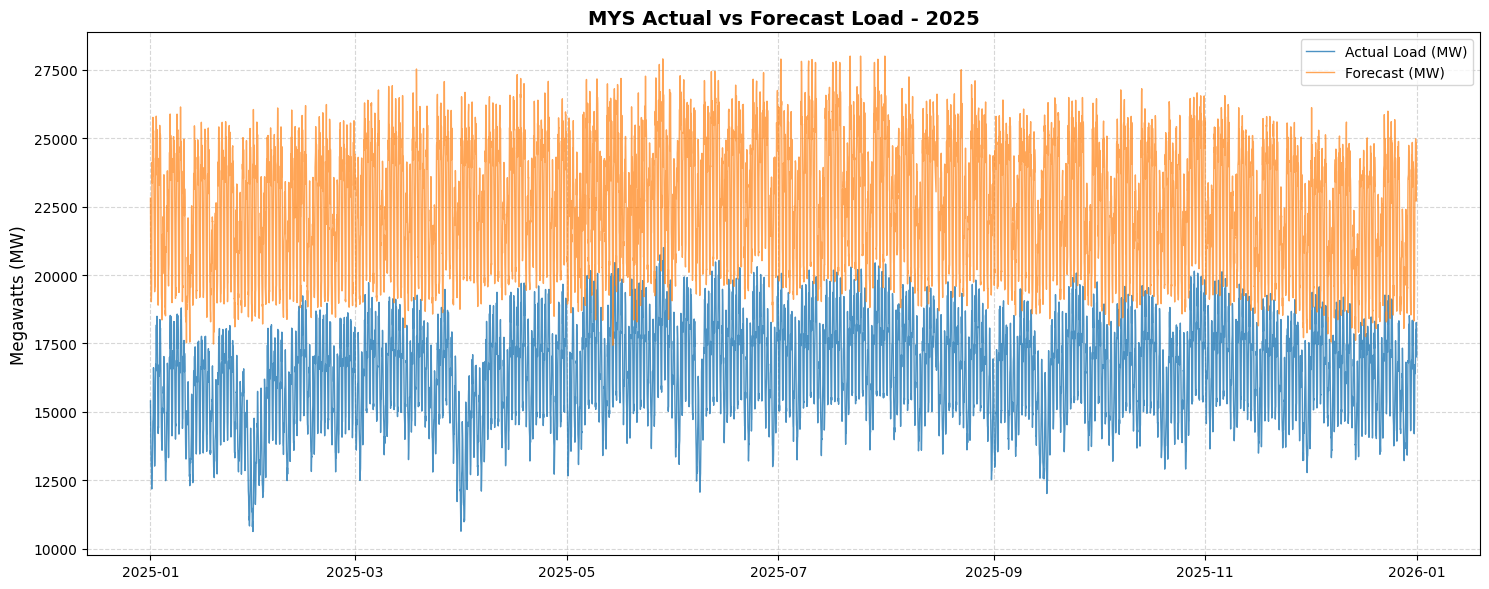

In [33]:
#Create the comparison graph
import matplotlib.pyplot as plt
from datetime import datetime 

df['Time (LOCAL)'] = pd.to_datetime(df['Time (LOCAL)'])

df['Year'] = df['Time (LOCAL)'].dt.year
years = sorted(df['Year'].unique())

fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(15, 6 * len(years)), sharex=False)

if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    # Filter data for the specific year
    yearly_data = df[df['Year'] == year]
    
    # Plot Actual Load (Blue)
    axes[i].plot(yearly_data['Time (LOCAL)'], yearly_data['Load (MW)'], 
                 label='Actual Load (MW)', color='#1f77b4', alpha=0.8, linewidth=1)
    
    # Plot Forecast Load (Red/Orange)
    axes[i].plot(yearly_data['Time (LOCAL)'], yearly_data['Forecast load (MW)'], 
                 label='Forecast (MW)', color='#ff7f0e', alpha=0.7, linewidth=1)
    
    # Formatting
    entity = df['Entity code'].unique().item()
    axes[i].set_title(f'{entity} Actual vs Forecast Load - {year}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Megawatts (MW)', fontsize=12)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Adjust layout to prevent overlapping text
plt.tight_layout()
# Save the high-resolution image to your folder
time_current = datetime.now().strftime('%Y%m%d-%H%M%S')
plt.savefig(f"Actual_vs_Forecast_{entity}_{time_current}.png", dpi=300)
plt.show()

In [34]:
# Error metrics

y_true = df['Load (MW)']
y_pred = df['Forecast load (MW)']

# Calculations
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse) # Or root_mean_squared_error(y_true, y_pred) in newer versions
mape = mean_absolute_percentage_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# Displaying results
print(f"MSE:  {mse:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape * 100:.2f}%")
print(f"R2 Score: {r2:.4f}")

MSE:  39764634.23 MW
RMSE: 6305.92 MW
MAPE: 37.95%
R2 Score: -11.0368
